# Big Data
# Tarea #3

Andrés Esquivel Valerio - 402500696

María Fernanda Granados Arias - 402200492

Liz Madriz Rivera - 117860659

In [100]:
#Import necesarios 
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col, count, when, isnan
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline

**Dataset**

Para el desarrollo de esta tarea se utilizará el conjunto de datos **Wine Quality Binary Classification**, el cual contiene información relacionada con vinos tintos y diversos factores fisicoquímicos que pueden influir en su calidad. Este conjunto de datos fue obtenido desde Kaggle y proviene originalmente del repositorio UCI Machine Learning Repository.

El dataset contiene 1599 registros y 12 variables. De estas, 11 corresponden a variables explicativas y 1 corresponde a la variable objetivo.

**Variable objetivo (quality):** corresponde a una clasificación binaria sobre la calidad vido. Originalmente, se encuentan agrupados en dos categorías: **good** y **bad**. 

Siendo así que el objetivo principal de esta tarea constiste en desarrollar modelos capaces de predecir si un vino es categorizado como de buena o mala calidad a partir de sus características fisioquímicas.

**Variables explicativas:**

- **Fixed acidity:** representa la cantidad de ácidos no volátiles presentes en el vino. Estos ácidos influyen en el sabor y la estabilidad del producto.
- **volatile acidity:** corresponde a los ácidos que pueden evaporarse fácilmente.
- **citric acid:** corresponde a la parte que contribuye a la frescura y sabor del vino.
- **residual sugar:** cantidad de azúcar que permanece en el vino después del proceso de fermentación.
- **chlorides:** oncentración de sales presentes en el vino.
- **free sulfur dioxide:** cantidad de dióxido de azufre disponible en el vino.
- **total sulfur dioxide:** suma del dióxido de azufre libre y combinado presente en el vino.
- **density:** medida relacionada con la concentración de alcohol y azúcares presentes en la bebida.
- **pH:** indicador del nivel de acidez o alcalinidad del vino.
- **sulphates:** compuestos que contribuyen a la preservación del vino y pueden influir en su sabor.
- **alcohol:** porcentaje de alcohol presente en el vino.

**Carga y limpieza de datos**

In [47]:
#Se define la sesión de Spark y se configura el conector JDBC para PostgreSQL
spark = SparkSession.builder \
    .appName("M4-T3").config("spark.jars","/opt/venv/lib/python3.10/site-packages/pyspark/jars/postgresql-42.7.3.jar") \
    .getOrCreate()

In [48]:
wine_schema = StructType([
    StructField("fixed acidity", DoubleType(), True),
    StructField("volatile acidity", DoubleType(), True),
    StructField("citric acid", DoubleType(), True),
    StructField("residual sugar", DoubleType(), True),
    StructField("chlorides", DoubleType(), True),
    StructField("free sulfur dioxide", DoubleType(), True),
    StructField("total sulfur dioxide", DoubleType(), True),
    StructField("density", DoubleType(), True),
    StructField("pH", DoubleType(), True),
    StructField("sulphates", DoubleType(), True),
    StructField("alcohol", DoubleType(), True),
    StructField("quality", StringType(), True)
])

In [49]:
df_wine = spark.read.csv(
    "data/wine.csv",
    header=True,
    schema=wine_schema
)

In [50]:
df_wine.show(5)

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|    bad|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|    bad|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|    bad|
|         11.2|            0.28|       0.56|           1.9|    0.075|               17.0|           

In [51]:
df_wine.printSchema()

root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: string (nullable = true)



In [52]:
print(f"Cantidad de registros: {df_wine.count()}")
print(f"Cantidad de variables: {len(df_wine.columns)}")

Cantidad de registros: 1599
Cantidad de variables: 12


In [53]:
#Revisión de valores nulos
df_wine.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_wine.columns
]).show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|      0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+



No se identificaron valores nulos en ninguna de las columnas del dataset. Por esta razón, no es necesario aplicar imputación ni eliminar registros.

In [54]:
df_wine = df_wine.withColumn(
    "label",
    when(col("quality") == "bad", 0)
    .when(col("quality") == "good", 1)
)

In [55]:
df_wine.groupBy("quality", "label").count().show()

+-------+-----+-----+
|quality|label|count|
+-------+-----+-----+
|   good|    1|  855|
|    bad|    0|  744|
+-------+-----+-----+



In [75]:
numeric_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

Se observa que la variable objetivo, **quality**, guardada en **label**, presenta una distribución relativamente equilibrada, con 744 registros en la categoría bad y 855 registros en la categoría good. Por lo tanto, no se observa un desbalance significativo entre las clases.

**Análisis Exploratorio de Datos**

In [76]:
#Configuración de estilo para gráficos
sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

In [77]:
df_wine_pd = df_wine.toPandas()

- **Análisis Univariable**

Se realiza un análisis univariable, con el fin de estudiar cada variable de forma individual, sin considerar todavía relaciones entre variables. Dicho análisis se enfoca tanto en el estudio de la variable objetivo como de las variables explicativas.

**Variable objetivo**

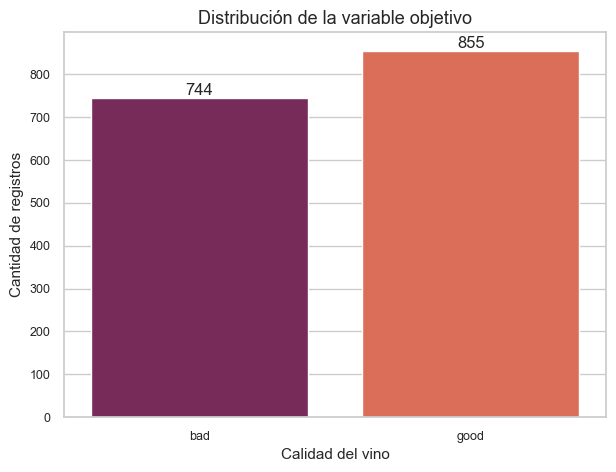

In [78]:
#Distribución de la variable objetivo
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_wine_pd,
    x="quality",
    hue="quality",
    palette="rocket",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Calidad del vino")
plt.ylabel("Cantidad de registros")

plt.show()

**Variables explicativas**

In [79]:
df_wine_pd[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


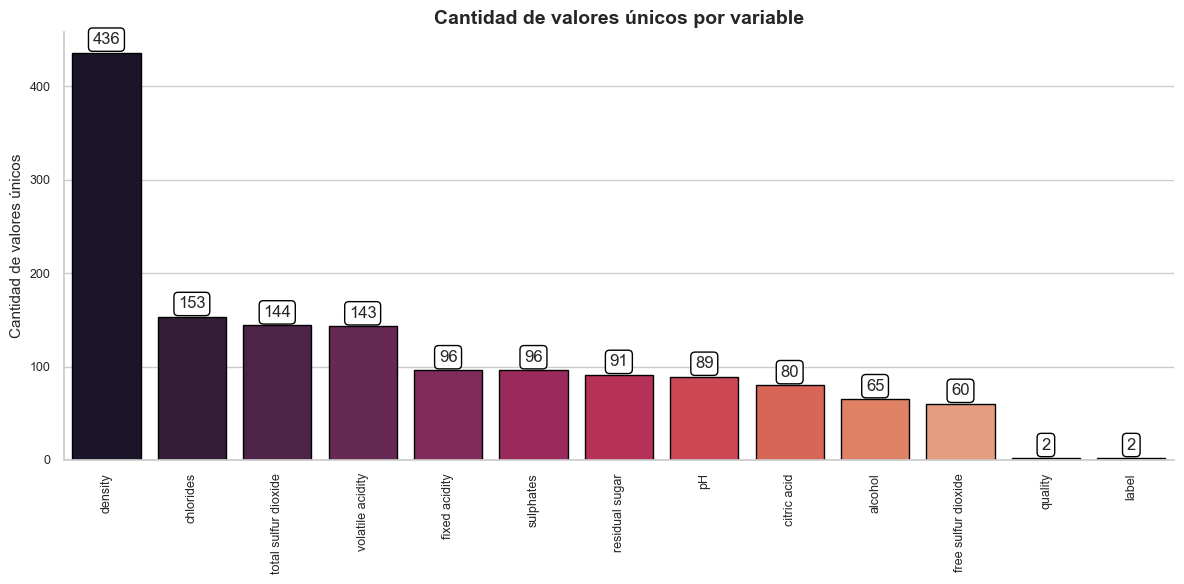

In [89]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=unique_values,
    x="variable",
    y="unique_values",
    hue="variable",
    palette="rocket",
    edgecolor="black",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=4,
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.25"
        )
    )

plt.title(
    "Cantidad de valores únicos por variable",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Cantidad de valores únicos")

plt.xticks(rotation=90)

sns.despine()

plt.tight_layout()
plt.show()

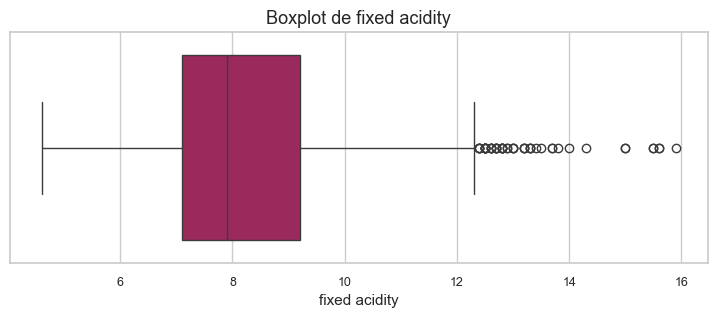

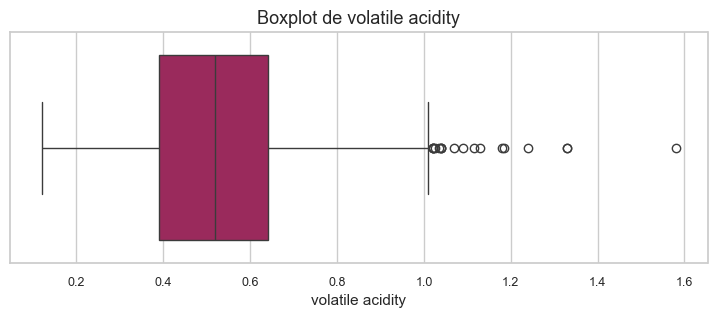

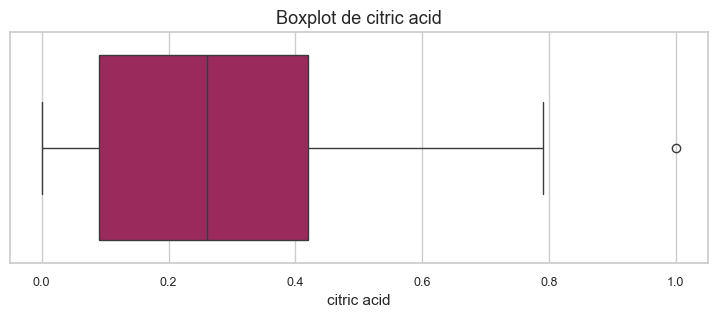

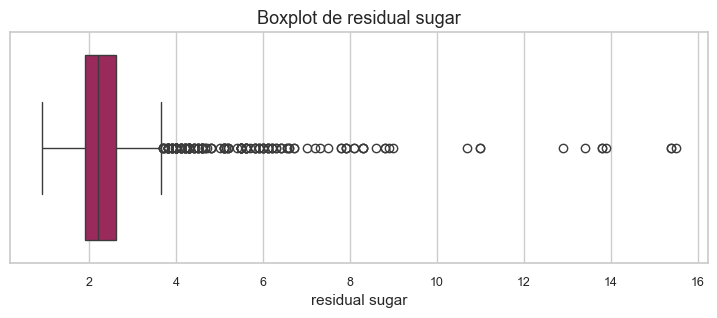

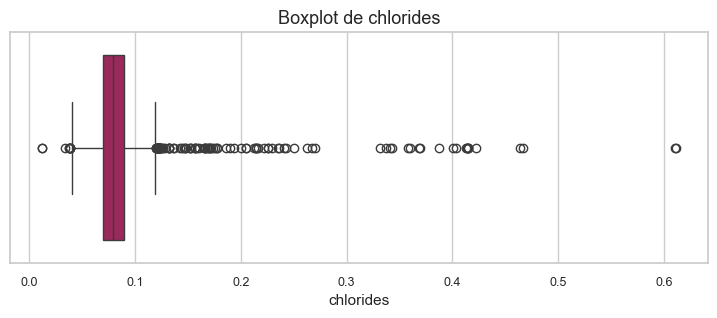

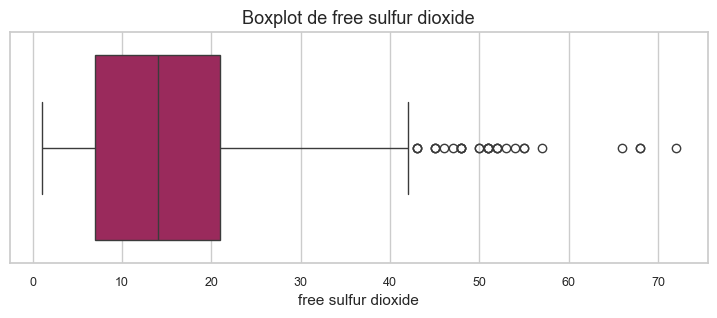

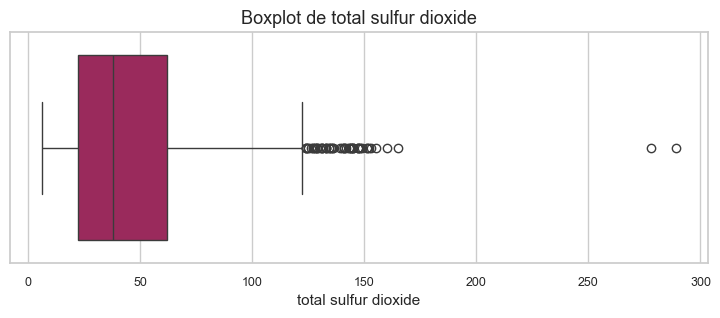

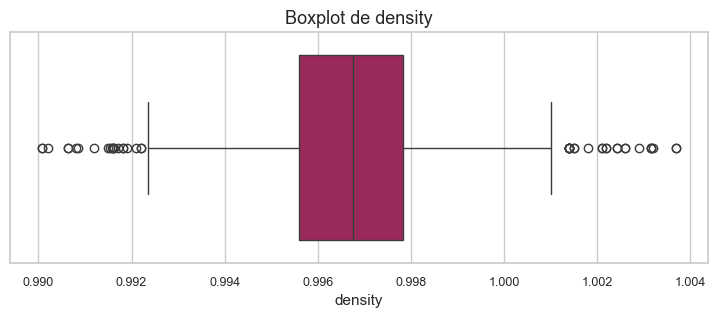

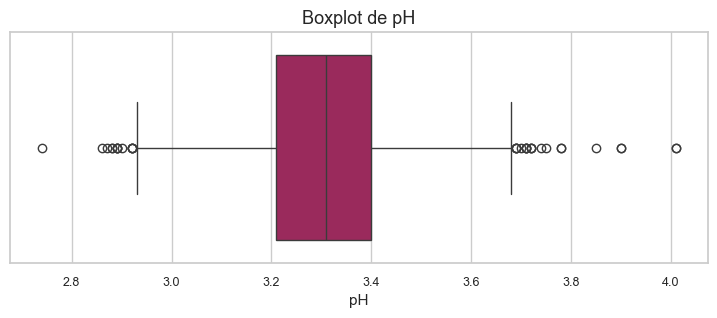

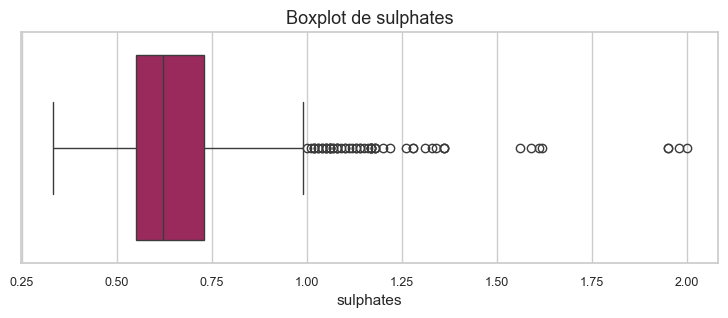

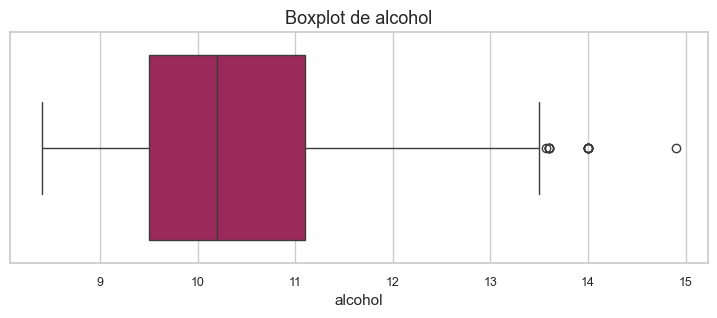

In [88]:
for variable in numeric_columns:
    plt.figure(figsize=(9, 3))
    
    sns.boxplot(
        data=df_wine_pd,
        x=variable,
        color=sns.color_palette("rocket")[2]
    )
    
    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    
    plt.show()

- **Análisis Multivariable**

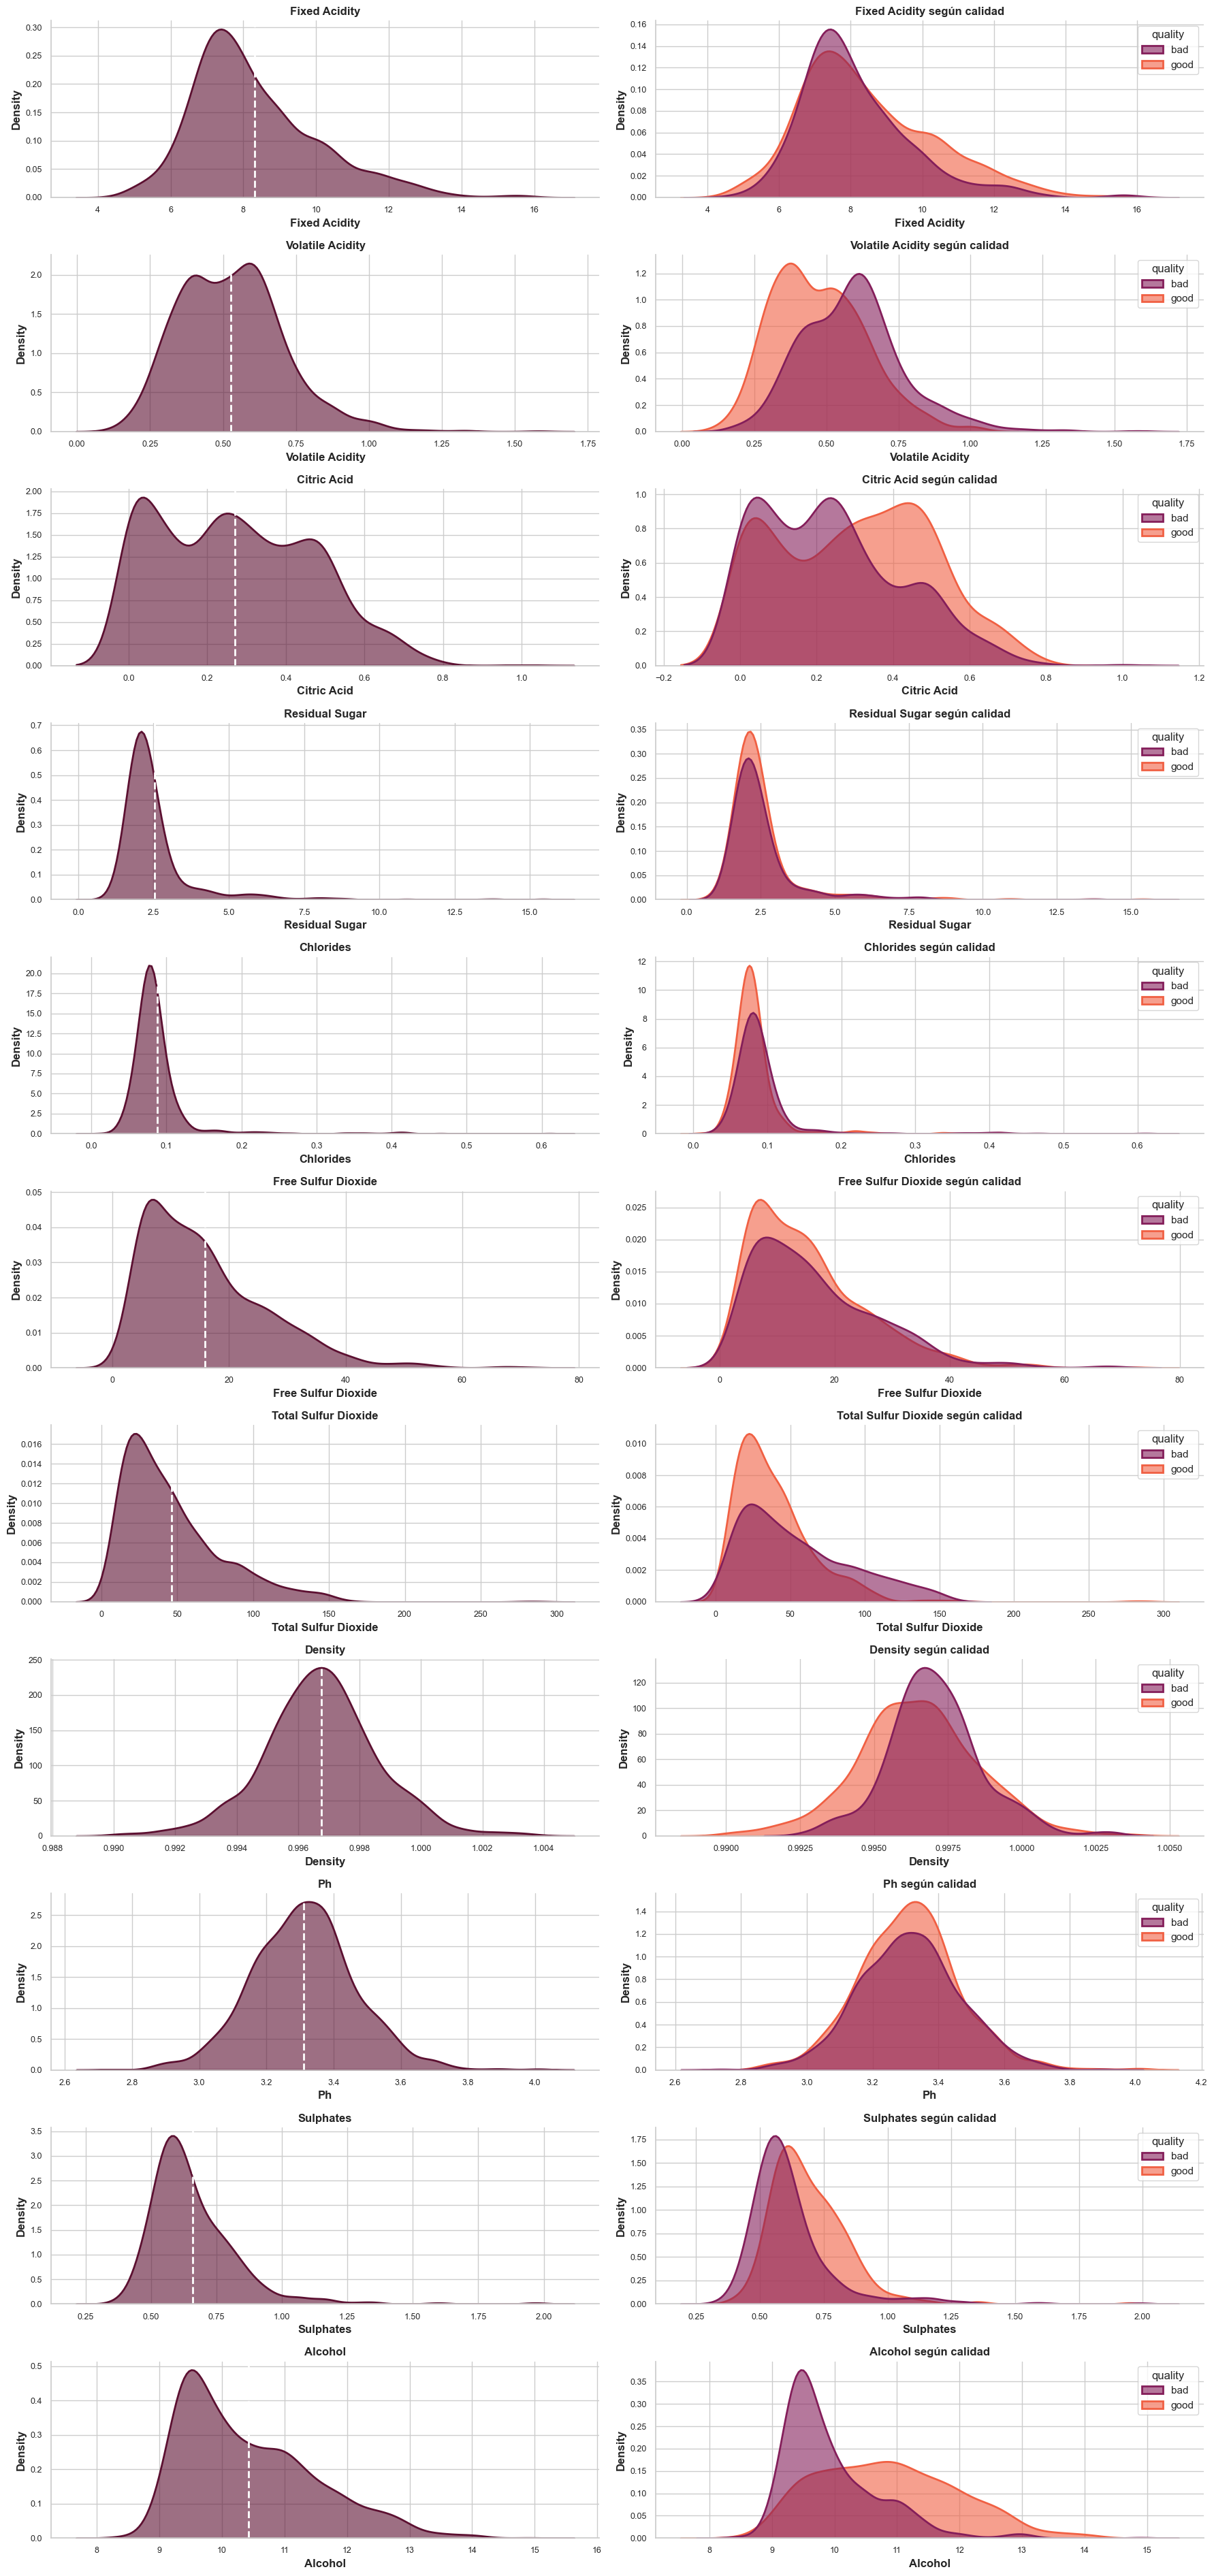

In [93]:
plot_index = 1

plt.figure(figsize=(18, 38))

for variable in numeric_columns:
    
    plt.subplot(11, 2, plot_index)
    
    sns.kdeplot(
        data=df_wine_pd,
        x=variable,
        fill=True,
        linewidth=2,
        color="#5c1031",
        alpha=0.6
    )
    
    plt.axvline(
        df_wine_pd[variable].mean(),
        color="white",
        linestyle="--",
        linewidth=2
    )
    
    plt.xlabel(variable.title(), fontsize=12, weight="bold")
    plt.ylabel("Density", fontsize=12, weight="bold")
    plt.title(variable.title(), fontsize=12, weight="bold")
    sns.despine()
    
    
    plt.subplot(11, 2, plot_index + 1)
    
    sns.kdeplot(
        data=df_wine_pd,
        x=variable,
        hue="quality",
        fill=True,
        linewidth=2,
        palette="rocket",
        alpha=0.6
    )
    
    plt.xlabel(variable.title(), fontsize=12, weight="bold")
    plt.ylabel("Density", fontsize=12, weight="bold")
    plt.title(f"{variable.title()} según calidad", fontsize=12, weight="bold")
    sns.despine()
    
    plot_index += 2

plt.tight_layout()
plt.show()

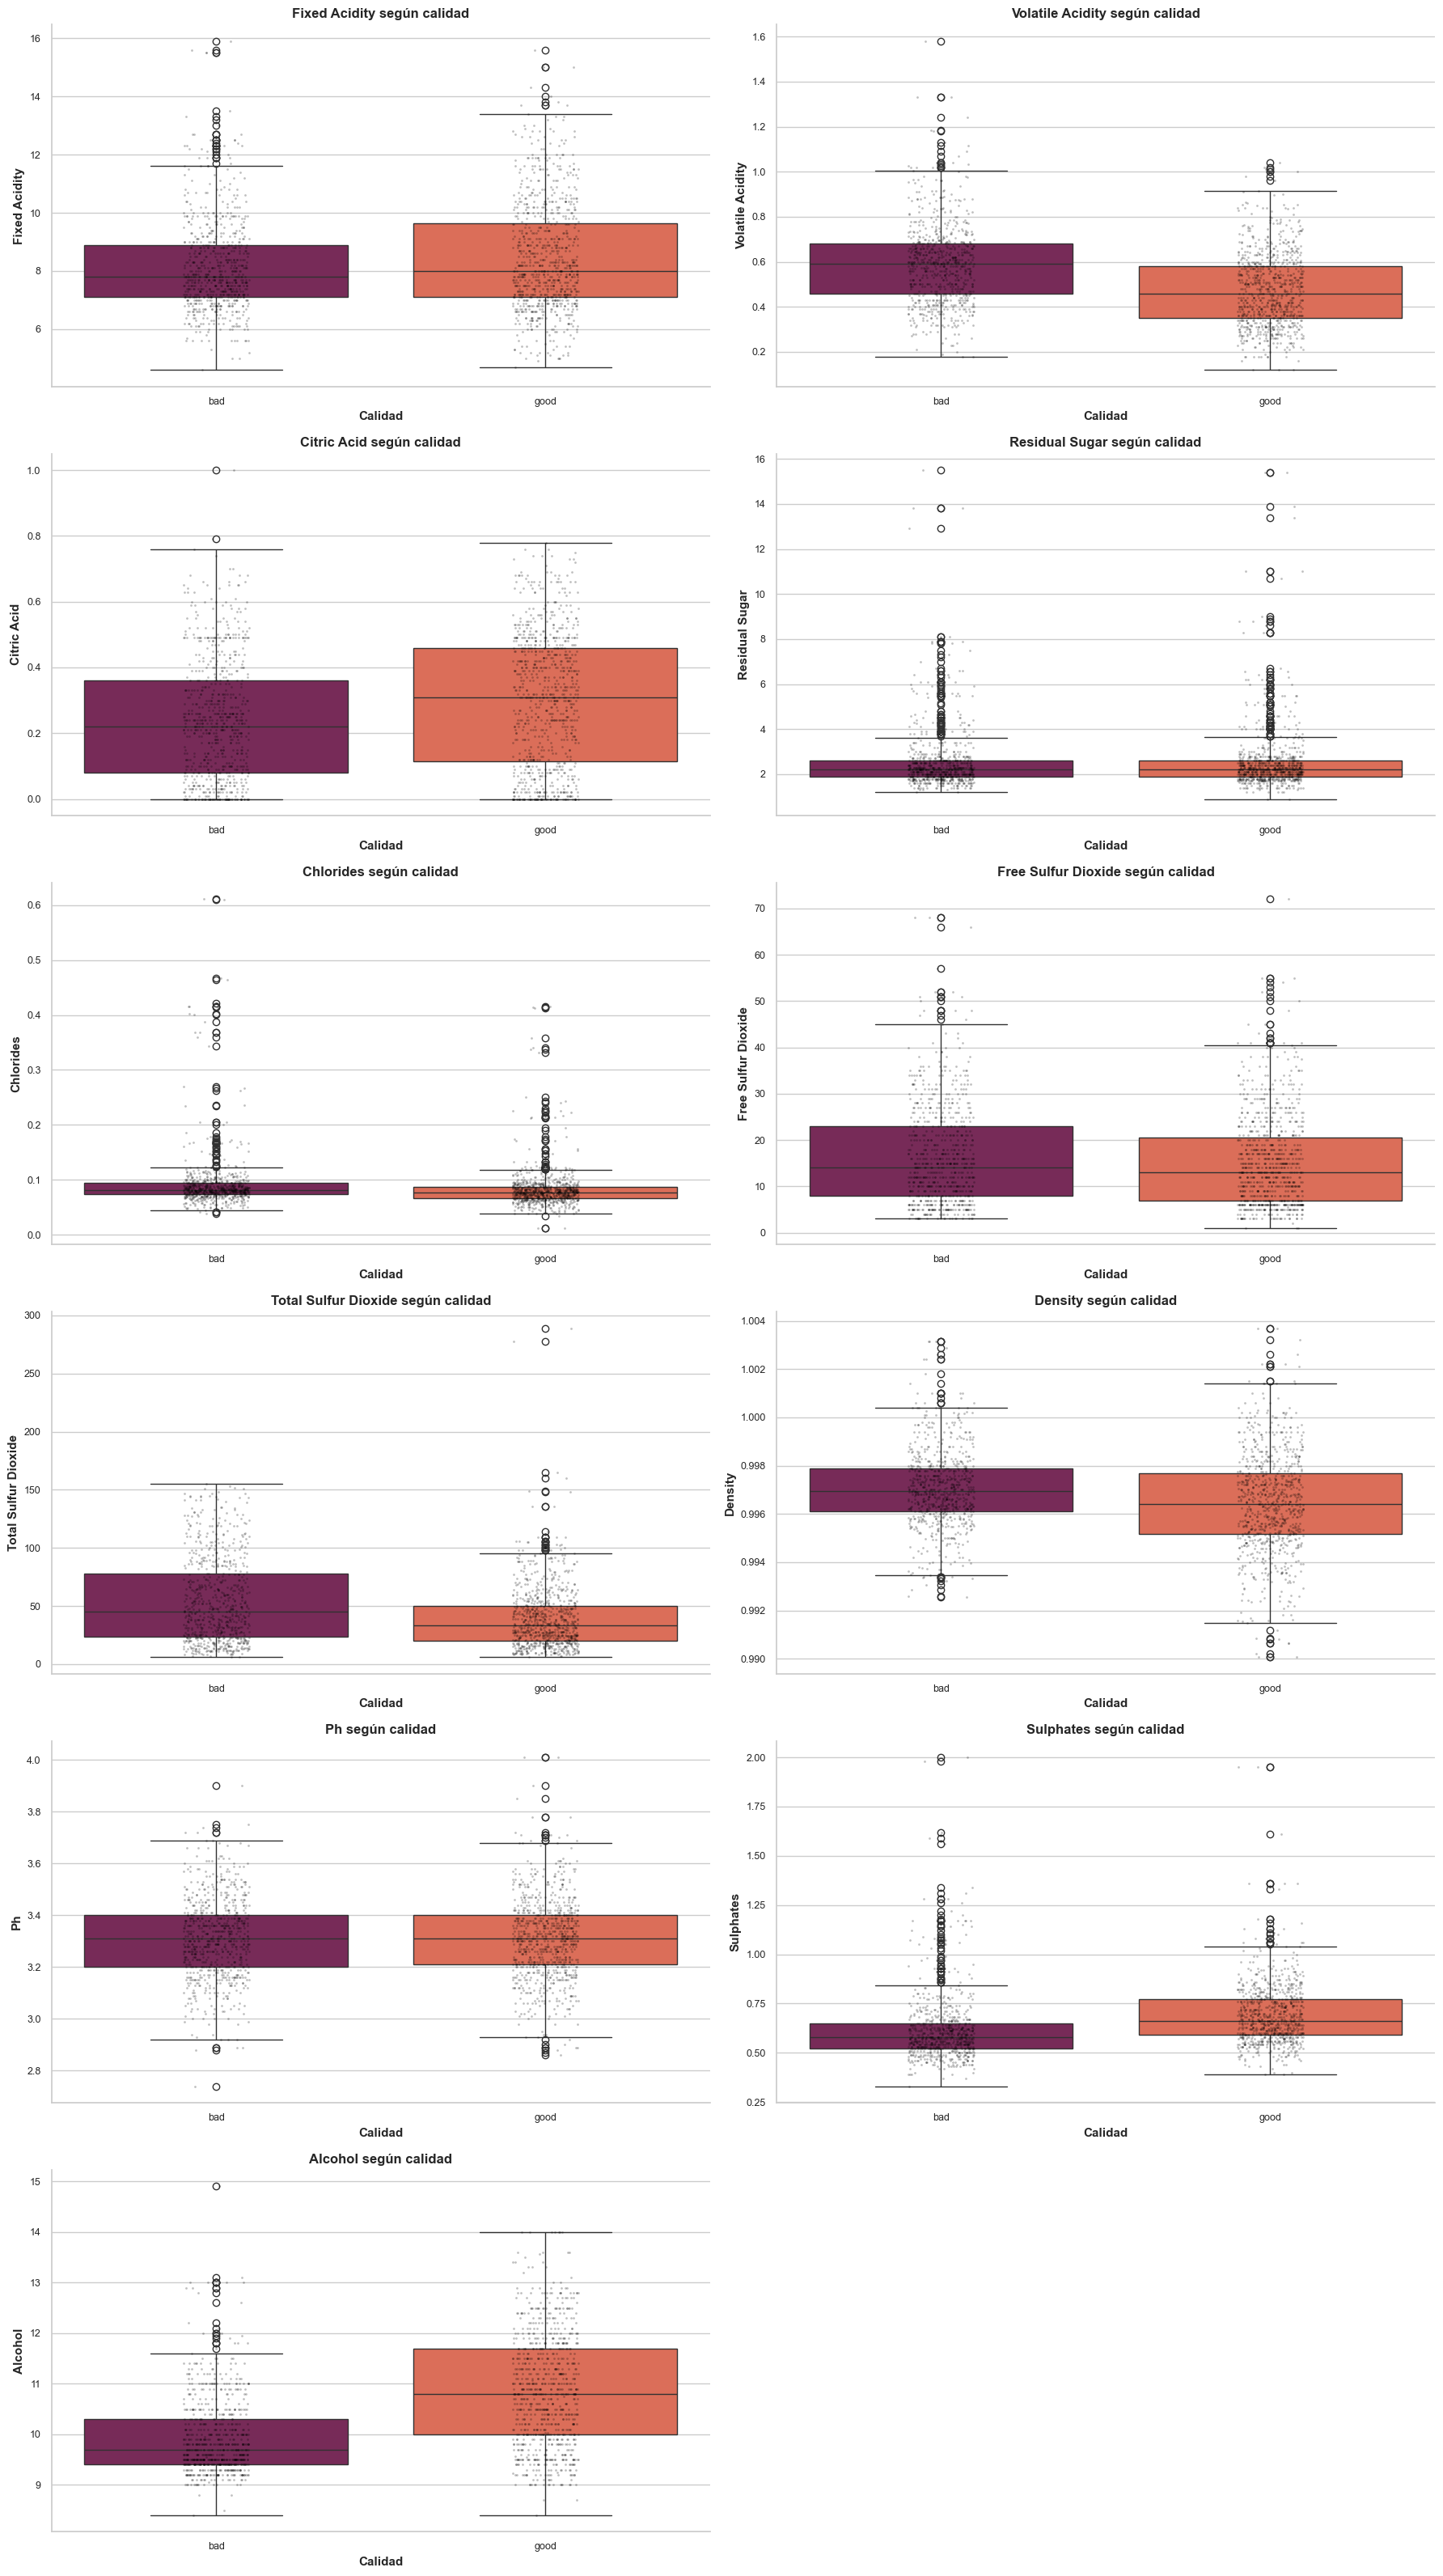

In [95]:
plt.figure(figsize=(18, 32))

plot_index = 1

for variable in numeric_columns:
    plt.subplot(6, 2, plot_index)

    sns.boxplot(
        data=df_wine_pd,
        x="quality",
        y=variable,
        hue="quality",
        palette="rocket",
        legend=False
    )

    sns.stripplot(
        data=df_wine_pd,
        x="quality",
        y=variable,
        color="black",
        alpha=0.25,
        size=2
    )

    plt.title(f"{variable.title()} según calidad", fontsize=12, weight="bold")
    plt.xlabel("Calidad", fontsize=11, weight="bold")
    plt.ylabel(variable.title(), fontsize=11, weight="bold")

    sns.despine()
    plot_index += 1

plt.tight_layout()
plt.show()

In [96]:
correlation_data = df_wine_pd[numeric_columns + ["label"]]

correlation_matrix = correlation_data.corr()

correlation_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.095093
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.321441
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.159129
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,-0.002160
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.109494
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.061757
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.231963
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.159110
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.003264
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.218072


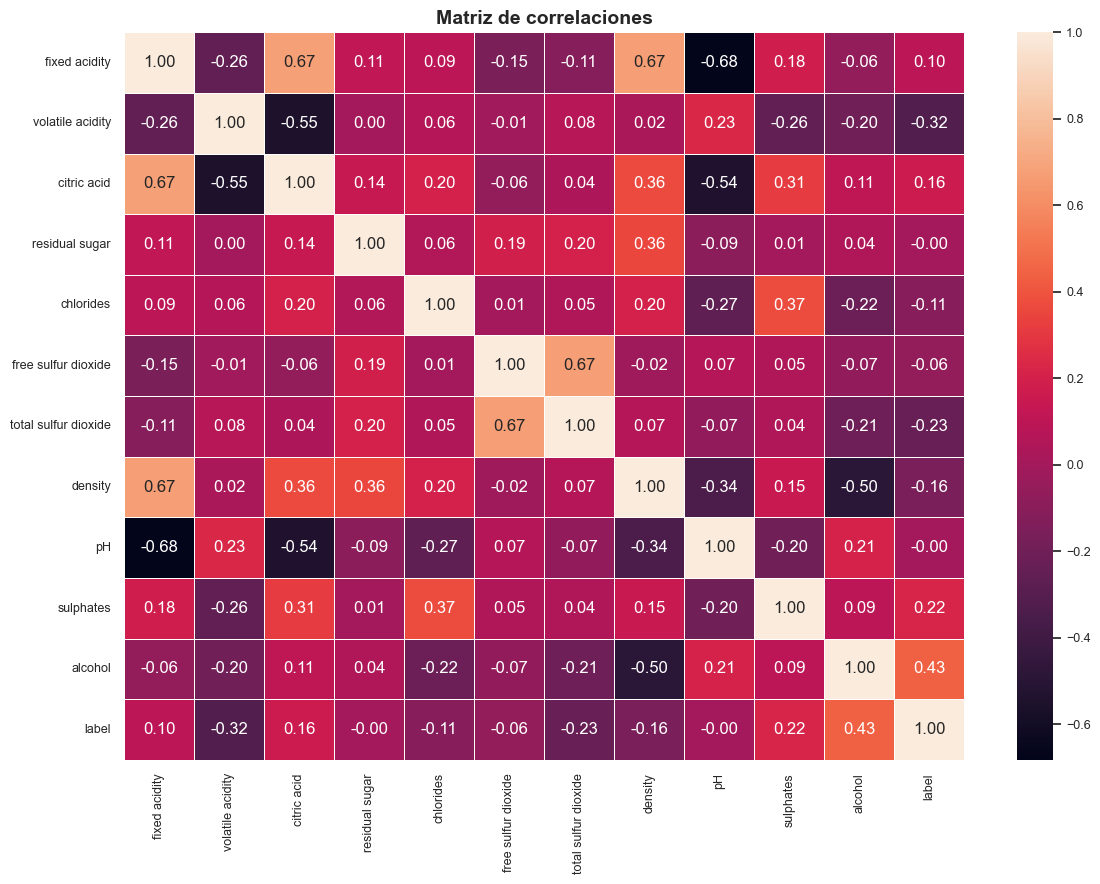

In [97]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="rocket",
    linewidths=0.5
)

plt.title("Matriz de correlaciones", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

In [98]:
target_correlation = (
    correlation_matrix["label"]
    .drop("label")
    .sort_values(ascending=False)
)

target_correlation

alcohol                 0.434751
sulphates               0.218072
citric acid             0.159129
fixed acidity           0.095093
residual sugar         -0.002160
pH                     -0.003264
free sulfur dioxide    -0.061757
chlorides              -0.109494
density                -0.159110
total sulfur dioxide   -0.231963
volatile acidity       -0.321441
Name: label, dtype: float64

C:\Users\lizmr\AppData\Local\Temp\ipykernel_20540\1417163984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


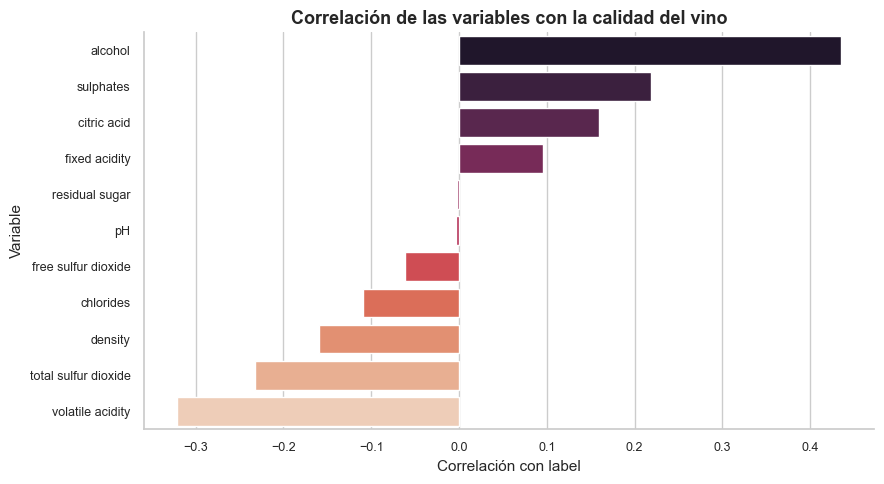

In [99]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index,
    palette="rocket"
)

plt.title("Correlación de las variables con la calidad del vino", fontsize=13, weight="bold")
plt.xlabel("Correlación con label")
plt.ylabel("Variable")

sns.despine()
plt.tight_layout()
plt.show()

**Normalización/Estandarización**

Las variables del conjunto de datos presentan escalas diferentes. Por ejemplo, variables como pH toman valores cercanos a 3 o 4, mientras que total_sulfur_dioxide puede alcanzar valores considerablemente mayores. Estas diferencias de magnitud pueden afectar el desempeño de algunos algoritmos de aprendizaje automático.

Por esta razón, se aplicará una técnica de estandarización utilizando la clase StandardScaler de Spark MLlib, con el objetivo de que las variables tengan una escala comparable antes del entrenamiento de los modelos.

In [101]:
feature_columns = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

In [102]:
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

df_wine_features = assembler.transform(df_wine)

In [103]:
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_wine_features)

df_wine_scaled = scaler_model.transform(df_wine_features)

**Escritura a base de datos**

In [104]:
tarea3 = df_wine.select(
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality",
    "label"
)

In [106]:
tarea3.show(5)
tarea3.printSchema()

print(f"Cantidad de registros a guardar: {tarea3.count()}")
print(f"Cantidad de columnas a guardar: {len(tarea3.columns)}")

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|label|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|    bad|    0|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|    bad|    0|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|    bad|    0|
|         11.2|            0.28|       0.56|           1.9|    0

In [ ]:
jdbc_url = "jdbc:postgresql://postgres-t3:5432/tarea3"
jdbc_propiedades = {"user":"tarea3","password":"tarea3","driver":"org.postgresql.Driver"}

In [ ]:
tarea3.write.jdbc(url=jdbc_url,table="tarea3",mode="overwrite",properties=jdbc_propiedades)